##### This script contains the following:

#### 1. Importing libraries and datasets
#### 2. Data Wrangling
#### 3. Reshaping
#### 4. Data Split
#### 5. Optimizing Hyperparameters
#### 6. Creating Random Forest with Optimized Hyperparameters
#### 7. Feature Importances


### 1. Importing libraries and datasets

In [5]:
# Importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [7]:
# Defining a path for importing/exporting
path = r'/Users/peterguan/ClimateWins ML'

In [9]:
# Importing the Cleaned Weather Observations dataset
climatewins_cleaned = pd.read_csv(r'/Users/peterguan/ClimateWins ML/Data Sets/climatewins_clean_weather_observations.csv', index_col = False)

In [11]:
# Checking if the dataset was imported successfully 
climatewins_cleaned.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,19600104,1,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,19600105,1,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [13]:
# Checking the dimensions
climatewins_cleaned.shape

(22950, 137)

In [15]:
# Importing the PLEASANT WEATHER dataset
pleasantweather = pd.read_csv(os.path.join(path, 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))

In [17]:
# Checking if the dataset was imported successfully 
pleasantweather.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [19]:
# Checking the dimensions
pleasantweather.shape

(22950, 16)

### 2. Data Wrangling

In [30]:
# Filtering CLIMATEWINS dataset to 2010s

climatewins_2010s = climatewins_cleaned[climatewins_cleaned['DATE'].astype(str).str.startswith('201')] 

# Checking if the filtering was successful 
climatewins_2010s

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
18263,20100101,1,8,0.93,0.9965,0.18,0.56,0.0,2.9,-0.2,...,-7.0,1,0.80,1.0121,0.43,0.00,6.0,1.7,-1.6,5.0
18264,20100102,1,3,0.74,1.0193,0.58,0.00,5.2,-1.5,-4.2,...,-7.1,1,0.82,1.0196,0.45,0.00,6.0,0.8,-4.5,6.2
18265,20100103,1,3,0.75,1.0226,0.61,0.00,6.3,-3.2,-6.0,...,-7.1,4,0.71,1.0196,0.36,0.41,1.6,0.5,-4.1,5.1
18266,20100104,1,5,0.83,1.0169,0.48,0.00,3.7,-4.9,-8.3,...,-3.6,2,0.67,1.0219,0.48,0.51,6.5,3.7,1.3,3.8
18267,20100105,1,7,0.78,1.0073,0.53,0.04,4.4,-4.0,-7.1,...,-5.5,4,0.78,1.0117,0.45,0.09,4.7,2.3,-0.7,5.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,20191227,12,8,0.92,1.0273,0.15,0.52,0.1,6.8,5.6,...,0.2,5,0.82,1.0142,0.04,0.41,3.4,10.7,7.9,13.5
21911,20191228,12,7,0.86,1.0380,0.35,0.00,1.3,3.7,-0.6,...,-1.0,5,0.82,1.0142,0.20,0.41,3.4,10.7,7.9,13.5
21912,20191229,12,6,0.93,1.0387,0.61,0.00,4.9,-0.8,-2.7,...,5.8,5,0.82,1.0142,0.24,0.41,3.4,10.7,7.9,13.5
21913,20191230,12,1,0.81,1.0354,0.64,0.00,6.5,0.5,-3.0,...,9.6,5,0.82,1.0142,0.06,0.41,3.4,10.7,7.9,13.5


In [32]:
# Filtering Pleasant dataset to 2010s
pleasantweather_2010s = pleasantweather[pleasantweather['DATE'].astype(str).str.startswith('201')] 

# Checking if the filtering was successful=
pleasantweather_2010s

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,20100101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,20100102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,20100103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,20100104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,20100105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,20191227,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21911,20191228,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21912,20191229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21913,20191230,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [34]:
# Dropping the 'DATE' and 'MONTH' columns from 2010s Cleaned dataset
climatewins_dropped_2010s = climatewins_2010s.drop(columns=['DATE', 'MONTH'])

In [36]:
# Checking the dimensions
climatewins_dropped_2010s.shape

(3652, 135)

In [38]:
# Dropping 'DATE' column from 2010s pleasant dataset
pleasantweather_dropped_2010s = pleasantweather_2010s.drop(columns=['DATE'])

# Checking dimensions
pleasantweather_dropped_2010s.shape

(3652, 15)

### 3. Reshaping

In [44]:
X = climatewins_dropped_2010s
y = pleasantweather_dropped_2010s

In [46]:
# Turning X and y from a dataframe to arrays

X = np.array(X)
y = np.array(y)

In [50]:
# Checking the dimensions 
X.shape

(3652, 135)

In [52]:
# Checking the dimensions
y.shape

(3652, 15)

### 4. Data Split

In [56]:
# Splitting data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 127)

In [58]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739, 15)
(913, 135) (913, 15)


### 5. Optimizing Hyperparamaters

In [62]:
# Create a RF classifier

clf = RandomForestClassifier()

In [64]:
# Grid search cv
grid_space={'max_depth':[3,5,10,None],
              'n_estimators':[10,100,200],
              'max_features':[15, 50, 100, 135], 
              'min_samples_leaf':[1,2,3],
              'min_samples_split':[1,2,3]
           }

In [68]:
start = time.time()
grid = GridSearchCV(clf, param_grid=grid_space, cv=3, scoring='accuracy', verbose=3, n_jobs=-2)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 432 candidates, totalling 1296 fits[CV 3/3] END max_depth=3, max_features=15, min_samples_leaf=1, min_samples_split=1, n_estimators=200;, score=nan total time=   0.0s
[CV 3/3] END max_depth=3, max_features=15, min_samples_leaf=1, min_samples_split=2, n_estimators=200;, score=0.442 total time=   1.1s
[CV 1/3] END max_depth=3, max_features=15, min_samples_leaf=2, min_samples_split=3, n_estimators=100;, score=0.412 total time=   0.5s
[CV 2/3] END max_depth=3, max_features=15, min_samples_leaf=3, min_samples_split=2, n_estimators=200;, score=0.433 total time=   1.0s
[CV 1/3] END max_depth=3, max_features=50, min_samples_leaf=1, min_samples_split=3, n_estimators=10;, score=0.426 total time=   0.1s
[CV 1/3] END max_depth=3, max_features=50, min_samples_leaf=1, min_samples_split=3, n_estimators=100;, score=0.440 total time=   1.3s
[CV 1/3] END max_depth=3, max_features=50, min_samples_leaf=2, min_samples_split=2, n_estimators=200;, score=0.437 total time=   2.6s
[C

/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
432 fits failed out of a total of 1296.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
432 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/opt/anaconda3/lib/python3.12/site-

Search took 5.385177763303121 minutes


In [70]:
# Print grid search results

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': None, 'max_features': 50, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best GRID search score is: 0.6422051843738591


In [72]:
# Define random search cv

rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(15, 135),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [74]:
# Create a RF classifier

clf2= RandomForestClassifier()

In [76]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=10, scoring='accuracy', verbose=3, n_jobs=-2, cv=3)
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Search took 1.6119580507278441 minutes


In [78]:
# Random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 70, 'max_features': 71, 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 410}
Best RANDOM search score is: 0.6389193136181088


### 6. Creating Random Forest with Optimized Hyperparameters

In [83]:
# Create a RF classifier with the best results from above
clf3 = RandomForestClassifier(n_estimators = 200, max_depth=None, max_features=50, min_samples_leaf=1, min_samples_split=2)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(max_features=50, n_estimators=200)

In [85]:
# Perform predictions on the test dataset
y_pred = clf3.predict(X_test)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.6779846659364732


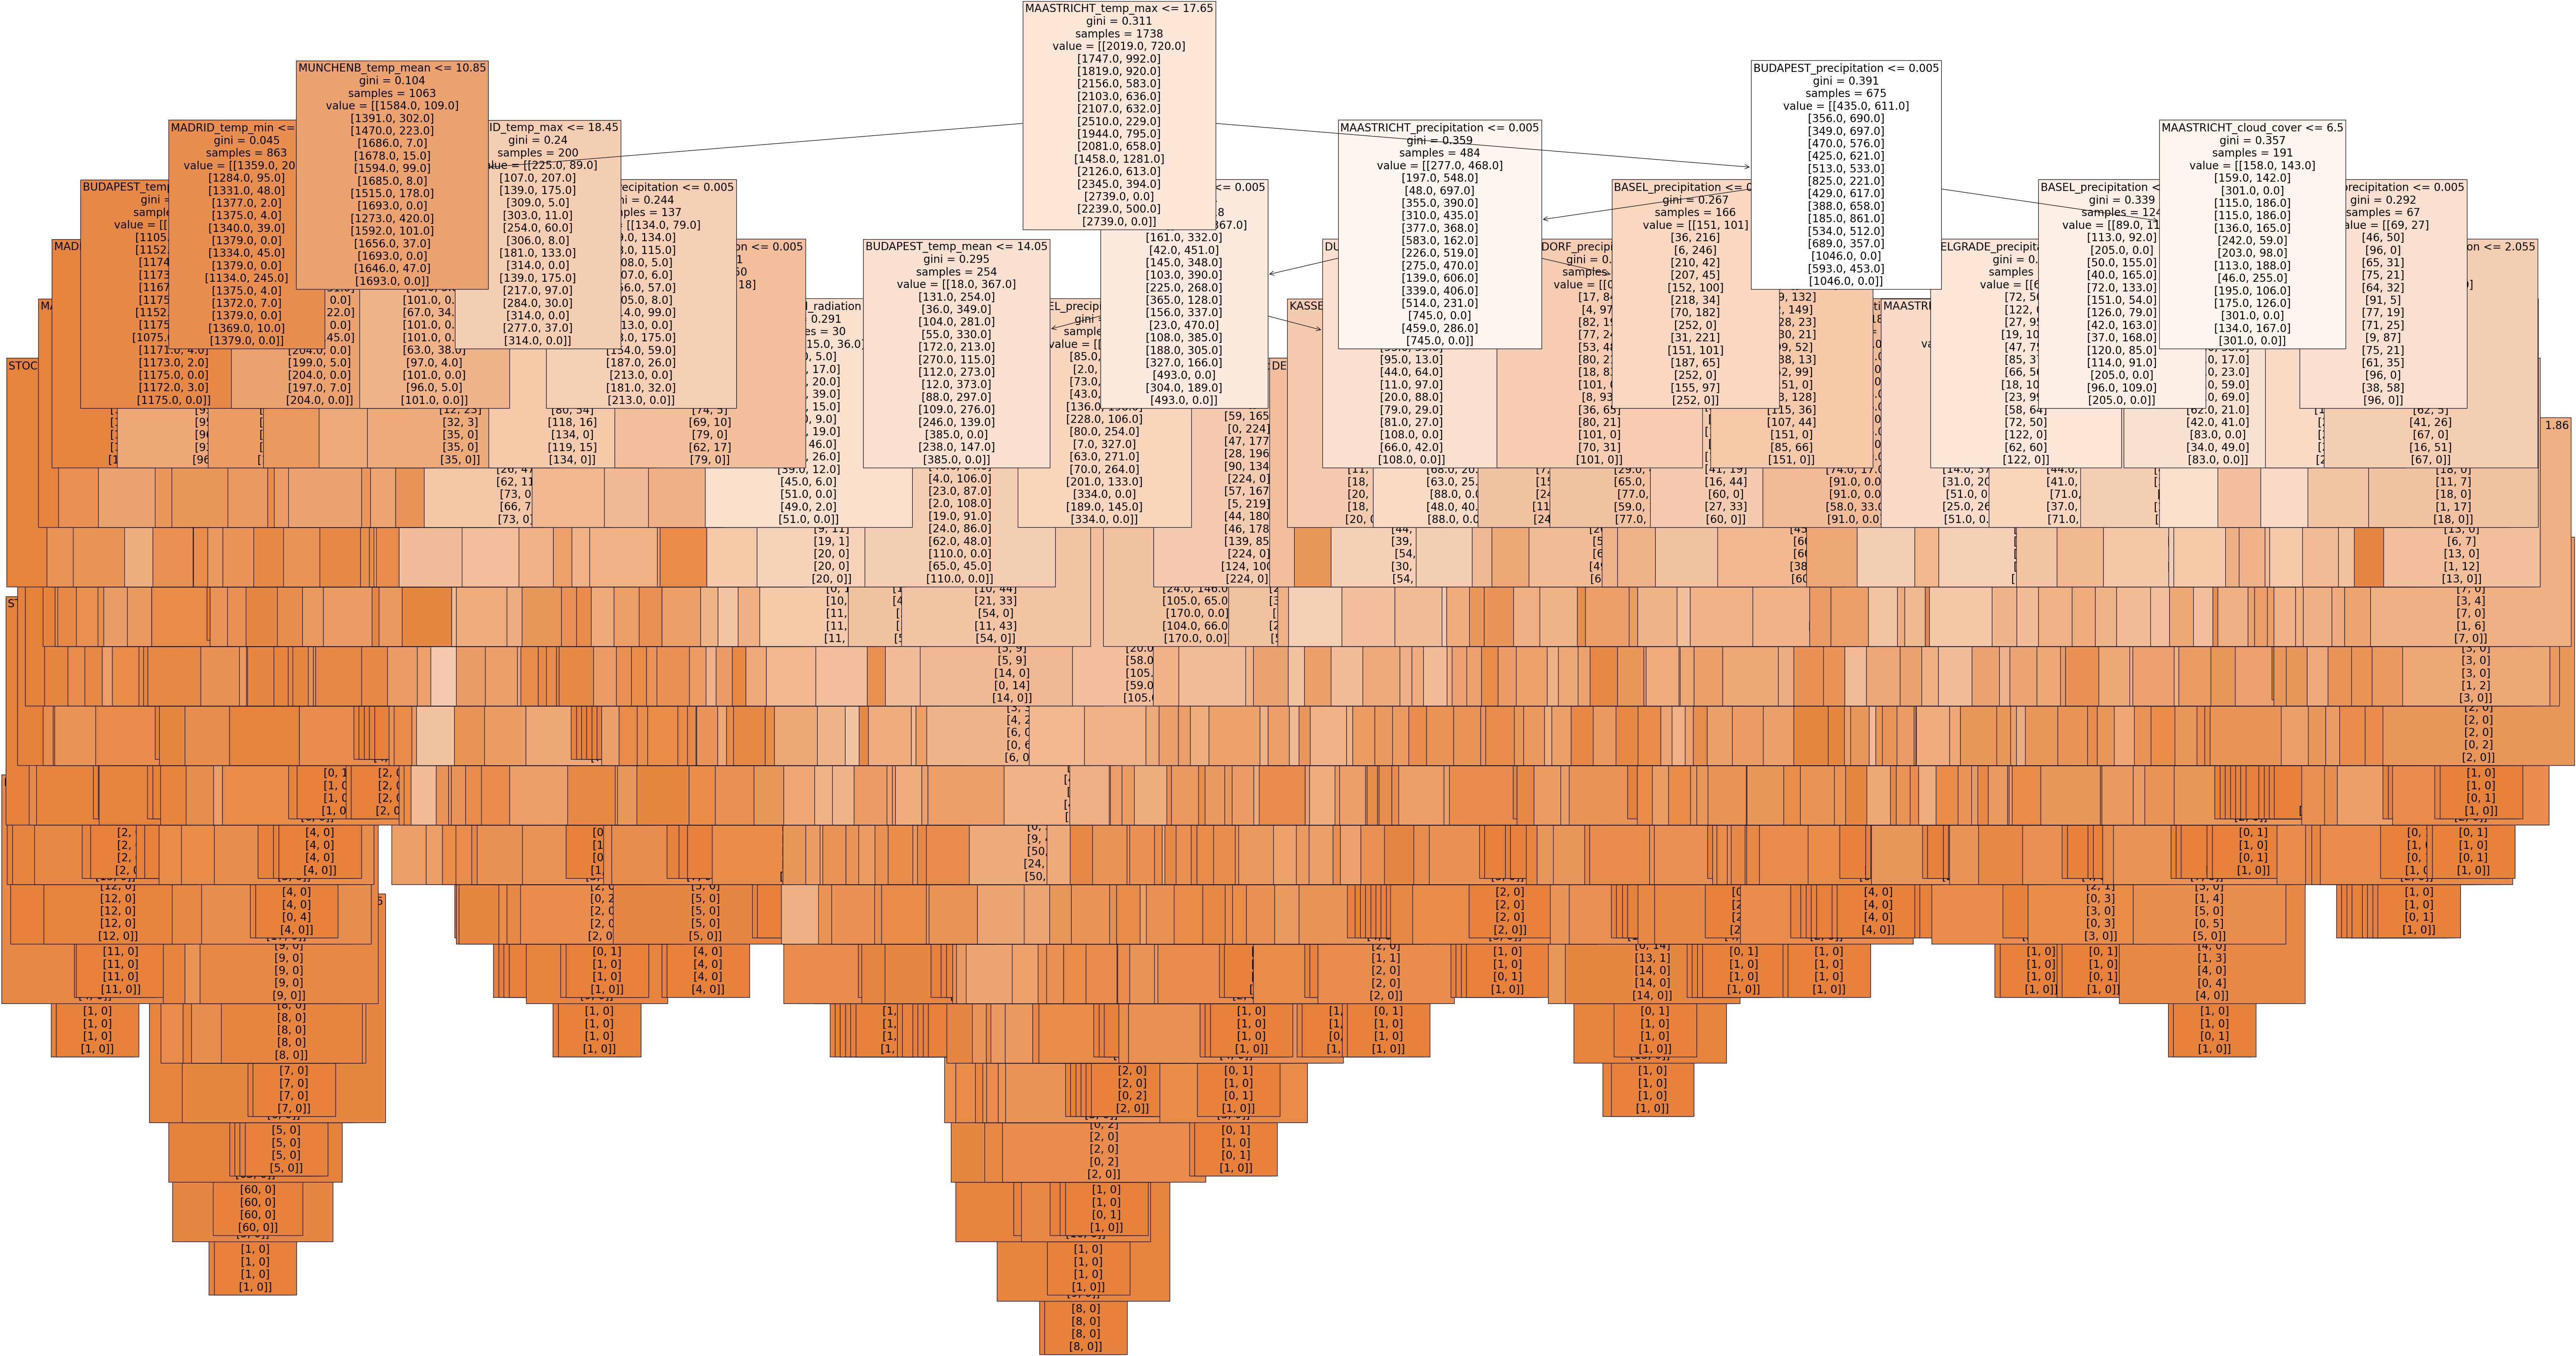

In [87]:
# Plotting the random forest
fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[15], fontsize = 20, feature_names = climatewins_dropped_2010s.columns, class_names=['unpleasant', 'pleasant'], filled=True);

### 7. Feature Importances

In [95]:
# Retrieve feature importances from the trained model

feature_importances_3 = clf3.feature_importances_
print(clf3.feature_importances_.shape)
feature_importances_3

(135,)


array([1.86859872e-03, 2.40125548e-03, 2.16638968e-03, 2.25969276e-03,
       2.94040894e-02, 4.68928804e-03, 1.10821860e-02, 1.80144435e-03,
       6.71720984e-02, 2.46962174e-03, 2.39171603e-03, 2.41374732e-03,
       2.17650205e-03, 2.91368986e-02, 2.26812547e-03, 3.65625537e-03,
       1.96104926e-03, 9.36228895e-03, 2.80703046e-04, 0.00000000e+00,
       0.00000000e+00, 8.57717752e-04, 2.65640007e-02, 9.07324286e-04,
       7.13298656e-03, 2.09131776e-03, 1.56277695e-02, 1.56928629e-03,
       2.17707460e-03, 2.38557044e-03, 2.67384315e-03, 1.84876984e-02,
       2.53039660e-03, 2.45716676e-03, 1.95768266e-03, 2.64394677e-02,
       1.35384370e-03, 1.80147836e-03, 2.30485610e-03, 1.95652335e-03,
       3.16453859e-02, 2.20334026e-03, 1.12202113e-02, 1.96595399e-03,
       1.12846710e-01, 1.92088348e-03, 3.12940204e-03, 2.60631659e-03,
       3.40970055e-03, 1.43230191e-02, 3.39094542e-03, 2.81982368e-03,
       2.07898384e-03, 8.87558651e-03, 1.80515993e-03, 1.80029113e-03,
      

In [97]:
# Reshape

feature_importances_3 = feature_importances_3.reshape(-1,15,9)
print(feature_importances_3.shape)
feature_importances_3

(1, 15, 9)


array([[[1.86859872e-03, 2.40125548e-03, 2.16638968e-03, 2.25969276e-03,
         2.94040894e-02, 4.68928804e-03, 1.10821860e-02, 1.80144435e-03,
         6.71720984e-02],
        [2.46962174e-03, 2.39171603e-03, 2.41374732e-03, 2.17650205e-03,
         2.91368986e-02, 2.26812547e-03, 3.65625537e-03, 1.96104926e-03,
         9.36228895e-03],
        [2.80703046e-04, 0.00000000e+00, 0.00000000e+00, 8.57717752e-04,
         2.65640007e-02, 9.07324286e-04, 7.13298656e-03, 2.09131776e-03,
         1.56277695e-02],
        [1.56928629e-03, 2.17707460e-03, 2.38557044e-03, 2.67384315e-03,
         1.84876984e-02, 2.53039660e-03, 2.45716676e-03, 1.95768266e-03,
         2.64394677e-02],
        [1.35384370e-03, 1.80147836e-03, 2.30485610e-03, 1.95652335e-03,
         3.16453859e-02, 2.20334026e-03, 1.12202113e-02, 1.96595399e-03,
         1.12846710e-01],
        [1.92088348e-03, 3.12940204e-03, 2.60631659e-03, 3.40970055e-03,
         1.43230191e-02, 3.39094542e-03, 2.81982368e-03, 2.07898384

In [99]:
# Collapse this shape into one observation for each weather station

collapsed_importances_3 = np.sum(feature_importances_3[0], axis=1)
collapsed_importances_3

array([0.12284504, 0.0558362 , 0.05346182, 0.06067819, 0.1672983 ,
       0.04255466, 0.02604119, 0.08744303, 0.14408873, 0.0731259 ,
       0.06474388, 0.0412922 , 0.0179507 , 0.03958772, 0.00305243])

In [101]:
# Extract stations list

stations = [col.split('_')[0] for col in climatewins_dropped_2010s.columns if '_' in col]

In [103]:
# Create a set of unique station names

unique_stations = set(stations)
unique_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [105]:
# Convert the set of unique stations to a list

unique_stations_list = list(unique_stations)

In [107]:
important = pd.Series(collapsed_importances_3, index = unique_stations_list)
important = important.sort_values(ascending = False)
important

KASSEL        0.167298
DUSSELDORF    0.144089
BASEL         0.122845
SONNBLICK     0.087443
OSLO          0.073126
VALENTIA      0.064744
BUDAPEST      0.060678
MAASTRICHT    0.055836
HEATHROW      0.053462
BELGRADE      0.042555
DEBILT        0.041292
MADRID        0.039588
MUNCHENB      0.026041
STOCKHOLM     0.017951
LJUBLJANA     0.003052
dtype: float64

In [109]:
# Creating a dataframe to associate weather stations with their importances

collapsed_importances_df_3 = pd.DataFrame({
    'Weather Station': unique_stations_list,
    'Importance': collapsed_importances_3
})

collapsed_importances_df_3 = collapsed_importances_df_3.sort_values(by='Importance', ascending = False)

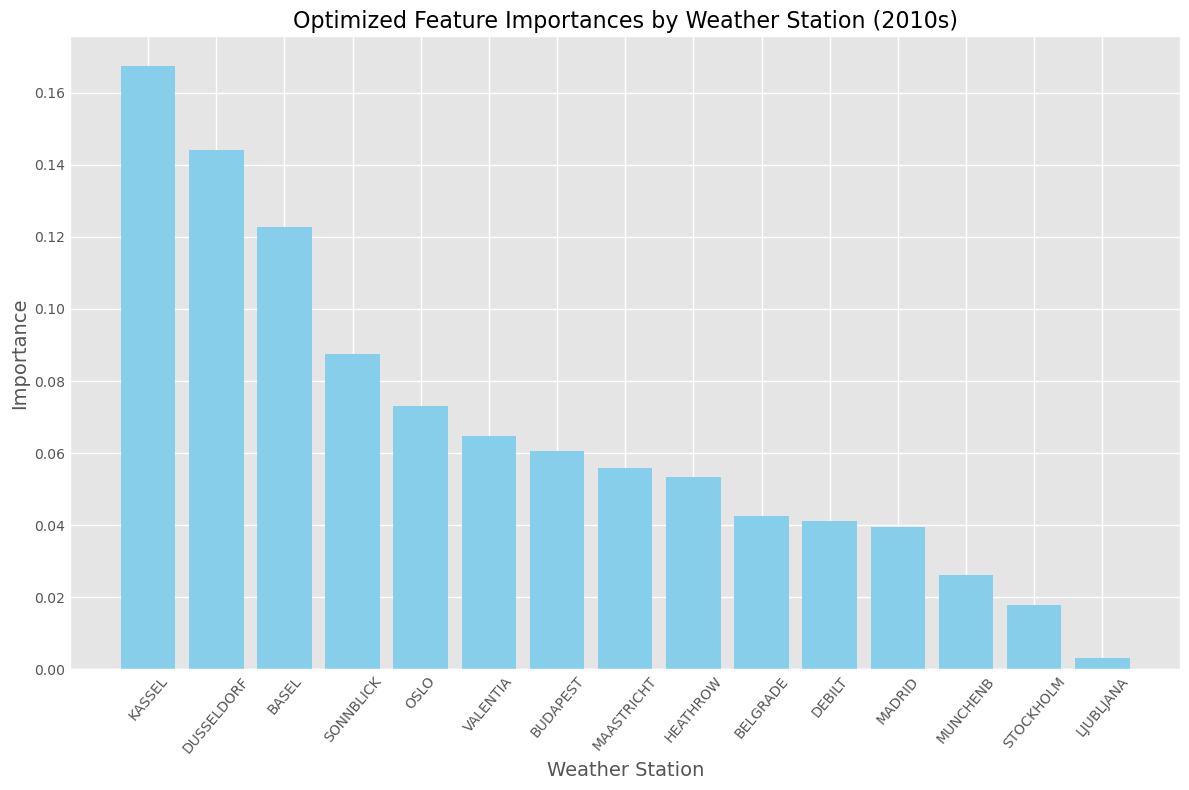

In [115]:
# Plotting the importances

plt.style.use('ggplot')
plt_1 = plt.figure(figsize=(12, 8))
plt.bar(collapsed_importances_df_3['Weather Station'], collapsed_importances_df_3['Importance'], color='skyblue')
plt.xticks(rotation=50, ha='center')
plt.xlabel('Weather Station', fontsize=14)
plt.ylabel('Importance', fontsize=14)
plt.title('Optimized Feature Importances by Weather Station (2010s)', fontsize=16)
plt.tight_layout()
plt.show()